# 数据可视化：读取 `data/` 目录中的实验数据

本 Notebook 用于在开发环境中快速浏览和分析 `../data` 目录中的压力控制相关数据（如 `pressure_*.csv`）。

主要功能：
- 列出 `data/` 目录中的可用数据文件
- 按文件名选择需要分析的记录
- 使用 pandas 读取并做基础统计
- 使用 Matplotlib / Seaborn 进行可视化
- 使用 ipywidgets 做简单交互式图表

In [6]:
# 导入依赖与路径设置
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']      # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False  
# 在 VS Code Notebook 中更适合使用 inline/自动后端
%matplotlib inline

# 定义数据目录（相对于当前 Notebook 所在 tools 目录）
DATA_DIR = (Path.cwd().parent / "data").resolve()
print("数据目录:", DATA_DIR)

# 如果目录不存在给出提示
if not DATA_DIR.exists():
    print("[警告] 数据目录不存在，请确认路径:", DATA_DIR)

数据目录: C:\Users\97503\share\stm32_HAL_project\data


In [2]:
# 列出 data 目录下的可用数据文件
from typing import List


def list_data_files(patterns: List[str] = None):
    if patterns is None:
        patterns = ["pressure_*.csv", "*.csv", "*.json"]
    files = []
    for pat in patterns:
        files.extend(sorted(DATA_DIR.glob(pat)))
    return files


data_files = list_data_files()
print(f"发现 {len(data_files)} 个数据文件")
for f in data_files:
    print(" -", f.name)

print("\n请在下一单元中通过文件名字符串手动指定要读取的文件，例如:")
print("selected_name = 'pressure_20251127_103355.csv'")

发现 26 个数据文件
 - pressure_20251127_103355.csv
 - pressure_20251127_103504.csv
 - pressure_20251127_105557.csv
 - pressure_20251127_121659.csv
 - pressure_20251127_122745.csv
 - pressure_20251127_123557.csv
 - pressure_20251127_124522.csv
 - pressure_20251127_124746.csv
 - pressure_20251127_143146.csv
 - pressure_20251127_143646.csv
 - pressure_20251127_144024.csv
 - pressure_20251127_144200.csv
 - pressure_20251127_144759.csv
 - pressure_20251127_103355.csv
 - pressure_20251127_103504.csv
 - pressure_20251127_105557.csv
 - pressure_20251127_121659.csv
 - pressure_20251127_122745.csv
 - pressure_20251127_123557.csv
 - pressure_20251127_124522.csv
 - pressure_20251127_124746.csv
 - pressure_20251127_143146.csv
 - pressure_20251127_143646.csv
 - pressure_20251127_144024.csv
 - pressure_20251127_144200.csv
 - pressure_20251127_144759.csv

请在下一单元中通过文件名字符串手动指定要读取的文件，例如:
selected_name = 'pressure_20251127_103355.csv'


In [3]:
# 读取所选文件的数据（通过手动输入文件名）
from pathlib import Path


def load_data(path: Path) -> pd.DataFrame:
    if path is None:
        raise ValueError("尚未选择有效的数据文件")
    try:
        if path.suffix.lower() == ".csv":
            df = pd.read_csv(path)
        elif path.suffix.lower() == ".json":
            df = pd.read_json(path)
        else:
            raise ValueError(f"不支持的文件类型: {path.suffix}")
        print("已读取文件:", path)
        display(df.head())
        print("\n数据基本信息:")
        display(df.info())
        return df
    except Exception as e:
        print("[错误] 读取数据失败:", e)
        raise


# 在这里手动指定要读取的文件名，例如:
selected_name = "pressure_20251127_124746.csv"  # 修改为你实际要分析的文件名

selected_path = DATA_DIR / selected_name
print("将要读取的文件:", selected_path)
if selected_path.exists():
    df = load_data(selected_path)
else:
    df = None
    print("指定的文件不存在，请检查文件名是否正确")

将要读取的文件: C:\Users\97503\share\stm32_HAL_project\data\pressure_20251127_124746.csv
已读取文件: C:\Users\97503\share\stm32_HAL_project\data\pressure_20251127_124746.csv


,timestamp,filtered_pressure,air_pressure,target_pressure
0,1.764219e+09,43298.0,101586,75000.0
1,1.764219e+09,43209.0,101586,75000.0
2,1.764219e+09,43367.0,101586,75000.0
3,1.764219e+09,43326.0,101586,75000.0
4,1.764219e+09,43858.0,101586,75000.0



数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          303 non-null    float64
 1   filtered_pressure  303 non-null    float64
 2   air_pressure       303 non-null    int64  
 3   target_pressure    303 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 9.6 KB


None

In [ ]:
# 数据清洗与基本统计信息（含相对时间计算）
if df is not None:
    # 若存在 timestamp 列，则增加从 0 开始、单位为秒的相对时间列
    if "timestamp" in df.columns:
        t0 = df["timestamp"].iloc[0]
        df["t_rel_s"] = df["timestamp"] - t0
        # 如果原始 timestamp 是 ns 级整数，可以转成秒
        if pd.api.types.is_integer_dtype(df["t_rel_s"]):
            df["t_rel_s"] = df["t_rel_s"] / 1e9
    print("缺失值统计:")
    display(df.isna().sum())

    print("\n数值列描述统计:")
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    display(df[numeric_cols].describe())

    # 示例：查看某些关键字段的分布（如果存在）
    for col in ["filtered_pressure", "air_pressure", "target_pressure", "mfc_opening"]:
        if col in df.columns:
            print(f"\n{col} 值计数（前 10 项）:")
            display(df[col].value_counts().head(10))
else:
    print("尚未加载数据，无法进行统计分析")

缺失值统计:


timestamp            0
filtered_pressure    0
air_pressure         0
target_pressure      0
dtype: int64


数值列描述统计:


,timestamp,filtered_pressure,air_pressure,target_pressure
count,3.030000e+02,303.000000,303.000000,303.0
mean,1.764219e+09,73154.425743,101589.673267,75000.0
std,9.484717e+00,5623.806892,1.931487,0.0
min,1.764219e+09,43209.000000,101586.000000,75000.0
25%,1.764219e+09,71025.000000,101588.000000,75000.0
50%,1.764219e+09,73362.000000,101591.000000,75000.0
75%,1.764219e+09,76419.000000,101591.000000,75000.0
max,1.764219e+09,79252.000000,101592.000000,75000.0



filtered_pressure 值计数（前 10 项）:


filtered_pressure
77967.0    2
73245.0    2
73156.0    2
77734.0    2
73210.0    2
78322.0    2
77327.0    2
77000.0    2
78253.0    1
75638.0    1
Name: count, dtype: int64


air_pressure 值计数（前 10 项）:


air_pressure
101591    125
101587     52
101590     40
101592     34
101586     21
101588     21
101589     10
Name: count, dtype: int64


target_pressure 值计数（前 10 项）:


target_pressure
75000.0    303
Name: count, dtype: int64

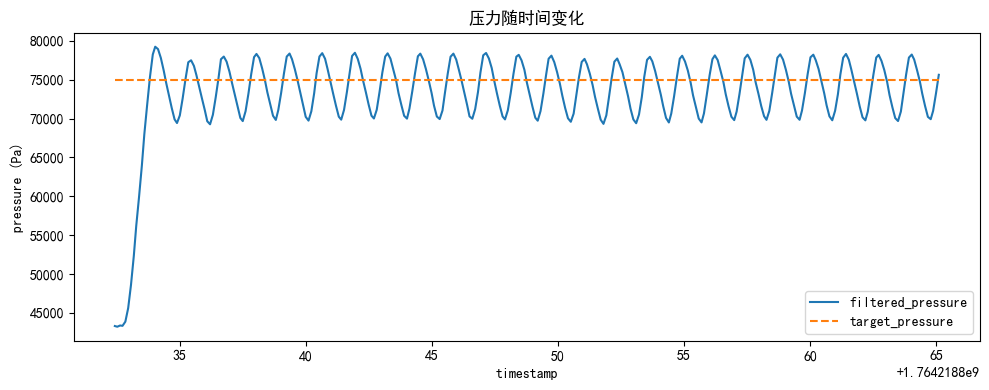

In [ ]:
# 使用 Matplotlib 进行基础可视化
if df is not None:
    # 示例：绘制时间序列（使用从 0 开始的相对时间秒 t_rel_s）
    time_col = None
    if "t_rel_s" in df.columns:
        time_col = "t_rel_s"
    elif "timestamp" in df.columns:
        time_col = "timestamp"
    
    if time_col is not None:
        plt.figure(figsize=(10, 4))
        plt.plot(df[time_col], df.get("filtered_pressure", pd.Series(index=df.index)), label="filtered_pressure")
        if "target_pressure" in df.columns:
            plt.plot(df[time_col], df["target_pressure"], label="target_pressure", linestyle="--")
        plt.xlabel("time (s)")
        plt.ylabel("pressure (Pa)")
        plt.title("压力随时间变化")
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    # 示例：MFC 开度随时间
    if time_col is not None and "mfc_opening" in df.columns:
        plt.figure(figsize=(10, 3))
        plt.plot(df[time_col], df["mfc_opening"], label="mfc_opening")
        plt.xlabel("time (s)")
        plt.ylabel("MFC opening")
        plt.title("MFC 开度随时间变化")
        plt.tight_layout()
        plt.show()
else:
    print("尚未加载数据，无法绘制图像")

In [ ]:
# 使用 Seaborn 进行高级可视化
if df is not None:
    sns.set_theme(style="whitegrid")

    # 分布直方图（例如 filtered_pressure）
    if "filtered_pressure" in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df["filtered_pressure"].dropna(), kde=True)
        plt.title("滤波气压分布")
        plt.tight_layout()
        plt.show()

    # 相关系数热力图
    numeric_cols = df.select_dtypes(include=["number"]).columns
    if len(numeric_cols) > 1:
        plt.figure(figsize=(6, 5))
        corr = df[numeric_cols].corr()
        sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
        plt.title("数值特征相关系数矩阵")
        plt.tight_layout()
        plt.show()
else:
    print("尚未加载数据，无法进行 Seaborn 可视化")

In [ ]:
# 交互式可视化与参数控制
if df is not None:
    import ipywidgets as widgets
    from ipywidgets import interact

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

    def plot_interactive(y_col: str):
        if y_col not in df.columns:
            print("列不存在:", y_col)
            return
        plt.figure(figsize=(10, 4))
        if "timestamp" in df.columns:
            plt.plot(df["timestamp"], df[y_col], label=y_col)
            plt.xlabel("timestamp")
        else:
            plt.plot(df[y_col].values, label=y_col)
            plt.xlabel("index")
        plt.ylabel(y_col)
        plt.title(f"{y_col} 随时间/索引变化")
        plt.legend()
        plt.tight_layout()
        plt.show()

    interact(
        plot_interactive,
        y_col=widgets.Dropdown(options=numeric_cols, description="Y 轴列:")
    )
else:
    print("尚未加载数据，无法进行交互式可视化")